# Functions

In [15]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from numba import njit
import pickle
from scipy.optimize import curve_fit

In [3]:
# PARAMETERS 
N = 10  
c = 1.0  
l_min = c
l_max = 1.3 * c
temperatures = [1.2, 0.7, 0.5, 0.4, 0.3] # beta crescenti, temperature decrescenti
epsilon = -1
h = 0.5

# Energy of the polymer 
def total_energy(polymer): 
    n=0
    for mon in polymer[1:]: # grafted monomer is not considered
        if mon[1] < h :
            n += 1
    return epsilon * n


# --------------  INITIAL CONFIGURATION OF THE POLYMER -> VERTICAL ----------------------
monomers = [(0, 0)]
for i in range(1, N):  # initial vertical configuration
    distance = random.uniform(l_min, l_max)
    x_new = 0  # configurazione verticale -> x = 0 per tutti i monomeri
    y_new = monomers[i - 1][1] + distance  # l'altezza del monomero n-esimo è data da: la coordinata y del monomero precedente + una distanza tra l_min e l_max
    monomers.append((x_new, y_new))



# distances among all monomers + y > 0 constraint
def valid(index, new_mon, polymer):
    for i in range(len(polymer)):
        if new_mon[1] < 0:
            return False
        if i != index:   
            distance = ((new_mon[0] - polymer[i][0])**2 + (new_mon[1] - polymer[i][1])**2)**0.5
            if distance < c:
                return False
    return True



# distance for consecutive monomers (used in the function that generates the small shift)
def valid_small(i, new_mon, polymer):
    # distanza tra il monomero candidato e il monomero precedente
    d1 = ((new_mon[0] - polymer[i - 1][0])**2 + (new_mon[1] - polymer[i - 1][1])**2)**0.5 
    if i + 1 < len(polymer): # se il monomero candidato è l'ultimo, allora non ha un monomero successivo e quindi è un caso particolare da trattare a parte
        # calcolo adesso la distanza tra il monomero candidato e il monomero successivo
        d2 = ((new_mon[0] - polymer[i + 1][0])**2 + (new_mon[1] - polymer[i + 1][1])**2)**0.5
        if d1 < l_min or d1 > l_max or d2 < l_min or d2 > l_max:
            return False
    else:
        if d1 < l_min or d1 > l_max:
            return False
    return True



# function that takes the single rotated monomer and tests if the distance with the previous rotated monomer is ok with the constraints
def valid_small_1(i, polymer):
    d1 = ((polymer[i][0] - polymer[i - 1][0])**2 + (polymer[i][1] - polymer[i - 1][1])**2)**0.5
    if i + 1 < len(polymer):
        d2 = ((polymer[i][0] - polymer[i + 1][0])**2 + (polymer[i][1] - polymer[i + 1][1])**2)**0.5
        if d1 < l_min or d1 > l_max or d2 < l_min or d2 > l_max:
            return False
    else:
        if d1 < l_min or d1 > l_max:
            return False
    return True

   
    
def test_Metropolis_shift(old, new, epsilon, beta):
    Valid_Metropolis = True
    if new[1] > h and old[1] < h:
        delta = - epsilon
        if random.random() > np.exp(- beta * delta):
            Valid_Metropolis = False
    return Valid_Metropolis




def block_shift(polymer, T):
    beta = 1 / T  

    for _ in range(N):
        i = random.randint(1, N - 1) # 1 and N-1 included, N-1 being the last monomer
        dx, dy = np.random.normal(0, 0.15, 2)
        new_mon = (polymer[i][0] + dx, polymer[i][1] + dy)
        
        if valid(i, new_mon, polymer) and valid_small(i, new_mon, polymer):
            old_mon = polymer[i]  

            if test_Metropolis_shift(old_mon, new_mon, epsilon, beta):
                polymer[i] = new_mon
            else:
                polymer[i] = old_mon  
    return polymer 



    
def block_pivot(polymer, T):
# list to store the new positions of the monomers belonging to a rotated branch
    new_branch = [] 
# random postion of the pivot excluding the last monomer
    j = random.randint(0, N - 2)
    if T < 0.45:  
        angle = random.uniform(-np.pi/4, np.pi/4)
    elif T >= 0.45 and T < 0.65:
        angle = random.uniform(-np.pi/2, np.pi/2)
    else:
        angle = random.uniform(-np.pi, np.pi)
    
    pivot = polymer[j]
 # first element of the new branch after rotation is initialized to the pivot itself
    new_branch.append(pivot) 
    E_old, E_new = 0, 0
    
# consider each monomer located after the pivot
    for k in range(j + 1, N):
    # calculation of the enrgy before the rotation:
        if polymer[k][1] < h:
            E_old -= 1
    # new coordinates after rotation:
        x_rel, y_rel = polymer[k][0] - pivot[0], polymer[k][1] - pivot[1]
        x_rot = x_rel * np.cos(angle) - y_rel * np.sin(angle)
        y_rot = x_rel * np.sin(angle) + y_rel * np.cos(angle)
    # candidate for the new, rotated monomer:
        rot_j = (pivot[0] + x_rot, pivot[1] + y_rot) 
        new_branch.append(rot_j)         
    
    polymer1 = polymer[:j] + new_branch  # excluding j. so polymer has elements from 0, 1,2,...,(j-1)   
    #Verifica la validità e aggiorna E_new se rot_j è accettabile
    for k in range(j + 1, N):    
        if valid(k, polymer1[k], polymer1) and valid_small_1(k, polymer1):
            if polymer1[k][1] < h:
                E_new -= 1
            
        else:
            return polymer  # Termina il passo se la rotazione non è valida

    # Test Metropolis per accettare la nuova configurazione
    if E_new < E_old or random.random() < np.exp(-(E_new - E_old) / T):
        return polymer1
    return polymer




# Simulation + swap

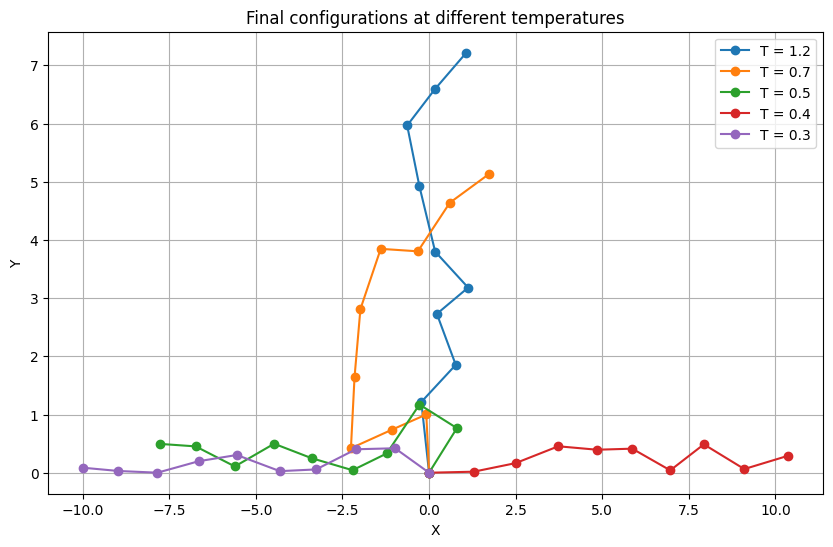

average swap rate: 48.468750%
below, the swap rate for each temperature:
[0.5526844  0.42322835 0.52414487 0.43985908]


In [4]:
# Simulation
time_steps = 80000
final_polymers = []
polymer = []
swap_ok = np.zeros(4)
swap_tries = np.zeros(4)

energies_per_T = {T: [] for T in temperatures} 
mean_energies_per_T = {T: [] for T in temperatures}
variance_mean_energy = {T: [] for T in temperatures}

temperature_indices = list(range(len(temperatures))) # array of T indices  
swap_attempts, successful_swaps = 0, 0


for i in range(len(temperatures)): # Creating an array of initial configurations, one for eache T 
    initial = monomers.copy()
    polymer.append(initial)

for  t in range(1, time_steps + 1):
    for j in range(len(temperatures)): # For each temperature at a given time t, do the block of moves   
        T_index = temperature_indices[j]
        current_T = temperatures[j]
    # BLOCK OF MOVES
        polymer[T_index] = block_shift(polymer[T_index], current_T) 
        polymer[T_index] = block_pivot(polymer[T_index], current_T)
    
    # Energy of the polymer
        E =  total_energy(polymer[T_index]) 
        energies_per_T[current_T].append(E)
              
    # Every 100 steps, averaging in blocks
        if t % 100 == 0: 
        # MEAN ENERGY EVERY 100 TIME STEP
            mean_energy = sum(energies_per_T[current_T][-100:]) / 100
            mean_energies_per_T[current_T].append(mean_energy)
        # VARIANCE OF MEAN ENERGY
            mean_square_en = sum(np.array(energies_per_T[current_T][-100:])**2) / 100
            v_mean_energy = mean_square_en - mean_energy**2
            variance_mean_energy[current_T].append(v_mean_energy) 


    # ------------------------------------  [  SWAP  ]  ---------------------------------------------
    # After the block of moves is done for each temperature and for some times, I try to swap 
    if t % len(temperatures) == 0:
        k = random.randint(0, len(temperatures) - 2) 
        i = temperature_indices[k] # assegno a i l'indice della temperatura estratta
        i_next = temperature_indices[k + 1] # i_next ha l'indice della temperatura successiva a quella estratta
        T1, T2 = temperatures[k], temperatures[k + 1] # prendi le temperature estratte
        E1, E2 = total_energy(polymer[temperature_indices[k]]), total_energy(polymer[temperature_indices[k + 1]]) 

        delta = (1 / T2 - 1 / T1) * (E2 - E1)  # se T2 > T1
        swap_attempts += 1 
        swap_tries[k] += 1
        if E2 > E1 or random.random() < np.exp(delta):  
            temperature_indices[k] = i_next
            temperature_indices[k+1] = i
            successful_swaps += 1
            swap_ok[k] += 1

    if t == time_steps: 
        final_polymers = [(temperatures[temperature_indices[j]], polymer[temperature_indices[j]]) for j in range(len(temperatures))]

# Visualizza le configurazioni finali
plt.figure(figsize=(10, 6))
for i, T in enumerate(temperatures):
    polymer_final = polymer[temperature_indices[i]]  # Configurazione finale del polimero per la temperatura T
    x_coords = [mon[0] for mon in polymer_final]
    y_coords = [mon[1] for mon in polymer_final]

    plt.plot(x_coords, y_coords, marker='o', label=f'T = {T}')


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Final configurations at different temperatures')
plt.legend()
plt.grid()
plt.show()


swap_rate = successful_swaps / swap_attempts if swap_attempts > 0 else 0
rate_perT = swap_ok / swap_tries
print(f"average swap rate: {swap_rate:%}")
print("below, the swap rate for each temperature:")
print(rate_perT)


In [5]:
print(rate_perT)
print(swap_tries)
print(swap_ok)

[0.5526844  0.42322835 0.52414487 0.43985908]
[3986. 4064. 3976. 3974.]
[2203. 1720. 2084. 1748.]


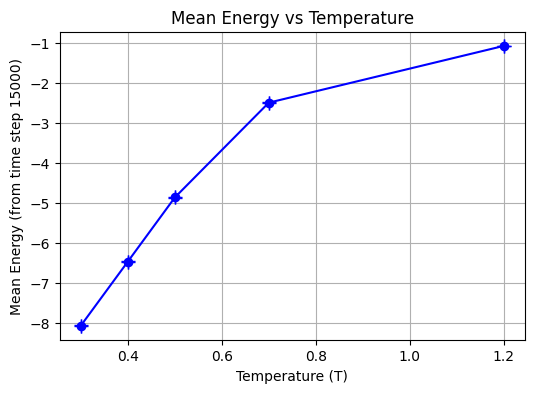

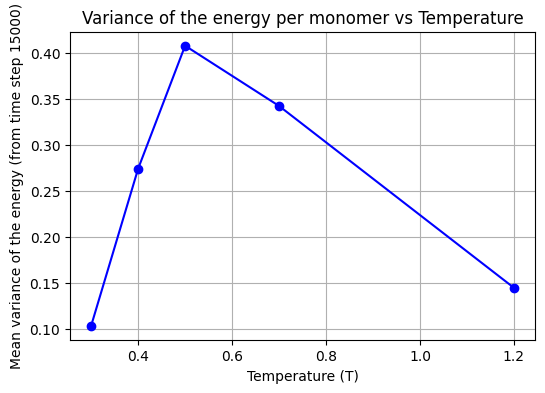

5 5 5


In [6]:
# Plot mean energy with respect temperatures
mean_energy_aftereq = {}
energies_aftereq = {}
mean_varenergy_aftereq = {}
errors_energy = {}
possible_energies = np.arange(0, -N, -1) 
N_energy = {T: {} for T in temperatures}

for T in temperatures:   
    energies_aftereq[T] = energies_per_T[T][30000:] # new dictionary considering energies after a given time
    mean = sum(energies_aftereq[T]) / len(energies_aftereq[T])
    square_var_en = sum(np.array(energies_aftereq[T])**2) / len(energies_aftereq[T]) 
    var = (square_var_en - mean**2) / N
    err = np.sqrt((var * N) / len(energies_aftereq[T])) 
    mean_energy_aftereq[T] = mean # filling a list of mean energies
    mean_varenergy_aftereq[T] = var
    errors_energy[T] = err

    # COUNTS IN ENERGY 
    for E in possible_energies:
        N_energy[T][E] = 0 # counts initialized to zero for each energy

    for E_eq in energies_aftereq[T]:
        N_energy[T][E_eq] += 1 # increment the count of the energy encountered        
       
mean_energies = [mean_energy_aftereq[T] for T in temperatures]
errors = [errors_energy[T] for T in temperatures]
xerror = np.zeros(len(temperatures))         
plt.figure(figsize=(6,4))
plt.errorbar(temperatures, mean_energies, xerr = xerror, yerr=np.array(errors), fmt='o', linestyle='-', color='blue', ecolor='blue', capsize=5)
plt.xlabel('Temperature (T)')
plt.ylabel('Mean Energy (from time step 15000)')
plt.title('Mean Energy vs Temperature')
plt.grid()
plt.show()


plt.figure(figsize=(6,4))
plt.plot(temperatures, [mean_varenergy_aftereq[T] for T in temperatures], marker='o', linestyle='-', color='blue')
plt.xlabel('Temperature (T)')
plt.ylabel('Mean variance of the energy (from time step 15000)')
plt.title('Variance of the energy per monomer vs Temperature')
plt.grid()
plt.show()

print(len(temperatures), len(mean_energies), len(errors))

-----    Sampling ogni tot  ------

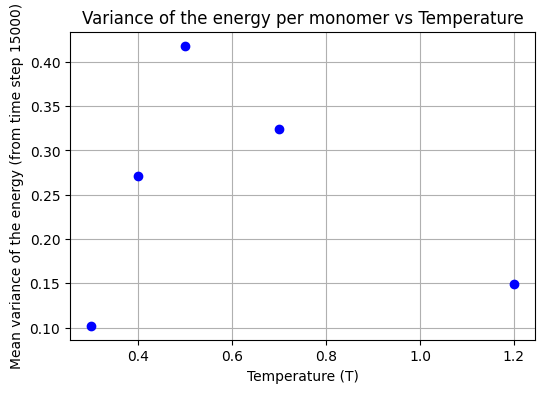

In [7]:
mean_energy_unc = {}
mean_varenergy_unc = {}
energies_unc = {T: energies_aftereq[T][::40] for T in temperatures}
for T in temperatures: 
    mean = sum(energies_unc[T]) / len(energies_unc[T])
    square_var_en = sum(np.array(energies_unc[T])**2) / len(energies_unc[T]) 
   # fluctuation per monomer 
    var = (square_var_en - mean**2) / N   
    mean_energy_unc[T] = mean # filling a list of mean energies
    mean_varenergy_unc[T] = var
plt.figure(figsize=(6,4))

plt.plot(temperatures, [mean_varenergy_unc[T] for T in temperatures], marker='o', linestyle='none', color='blue')
plt.xlabel('Temperature (T)')
plt.ylabel('Mean variance of the energy (from time step 15000)')
plt.title('Variance of the energy per monomer vs Temperature')
plt.grid()
plt.show()

# COUNTS IN ENERGY 
N_energy_unc = {T: {} for T in temperatures}
for T in temperatures:
    for E in possible_energies:
        N_energy_unc[T][E] = 0 # counts initialized to zero for each energy

    for E_eq in energies_aftereq[T]:
        N_energy_unc[T][E_eq] += 1 # increment the count of the energy encountered        
       

Plot energie

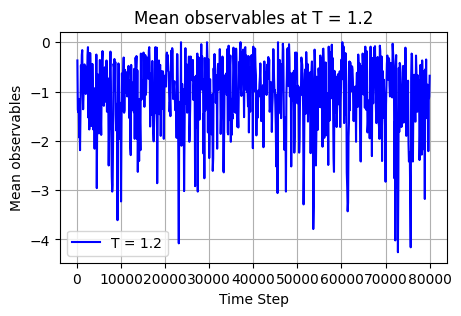

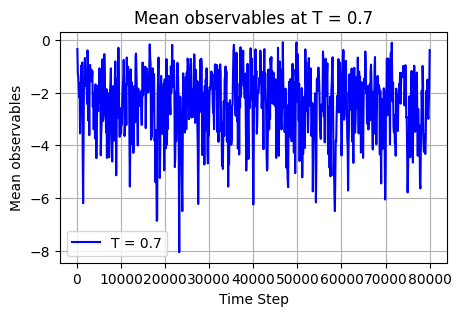

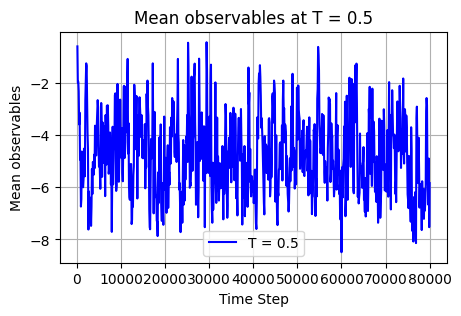

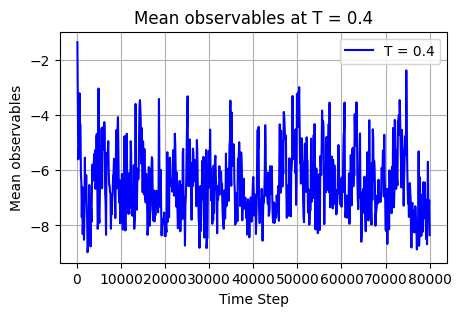

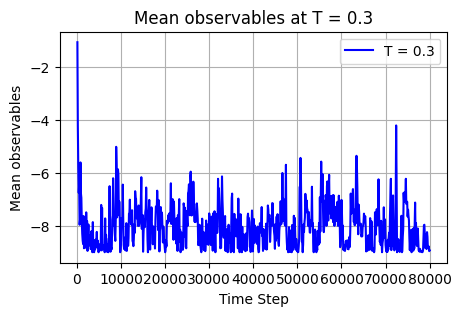

In [8]:
for T, mean_energies in mean_energies_per_T.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(100, time_steps + 1, 100), mean_energies, label=f'T = {T}', color='blue')
    plt.xlabel('Time Step')
    plt.ylabel('Mean observables')
    plt.title(f'Mean observables at T = {T}')
    plt.legend()
    plt.grid()
    plt.show()

# autocorrelation functions

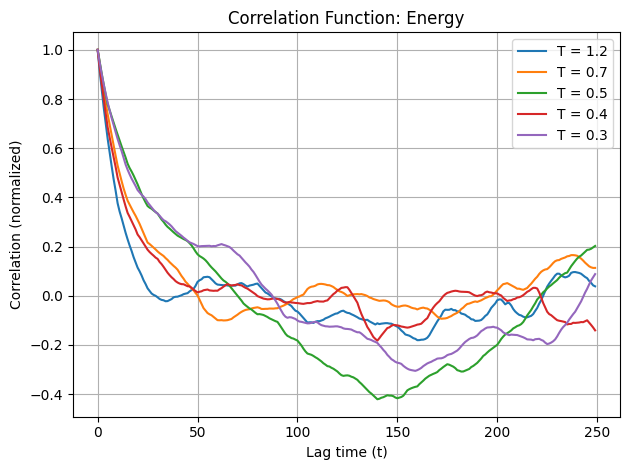

[np.float64(9.830989454343905), np.float64(16.27133289071343), np.float64(24.529992291175233), np.float64(15.255078075435053), np.float64(28.20730957261322)]


In [9]:
def corr_function(O):
    t_max = len(O)
    C_t = []
    max_t = int(t_max * 0.5)
    
    for t in range(max_t):
        sum1 = 0
        sum2 = 0
        sum3 = 0
        count = t_max - t
        
        for t_prime in range(count):
            sum1 += O[t_prime] * O[t_prime + t]
            sum2 += O[t_prime]
            sum3 += O[t_prime + t]
        
        C_t.append((sum1 / count) - (sum2 / count) * (sum3 / count))
    
    if C_t[0] != 0:  
        C_t = [value / C_t[0] for value in C_t]
    
    return C_t

# ----------------------------

sample = 500
corr_means = {}
taus = []
for j in range(len(temperatures)): 
    C_t_list = []
    for i in range(5):
        dx = (i + 1) * sample
        sx = i * sample
        C_t_energy = corr_function(energies_aftereq[temperatures[j]][sx:dx])
        C_t_list.append(np.array(C_t_energy))

    corr_means[temperatures[j]] = np.mean(C_t_list, axis=0) # this calculate the average element by element for 5 correlation functions
    
    plt.plot(corr_means[temperatures[j]], label=f'T = {temperatures[j]}')
    t = 0
    for i in range(len(corr_means[temperatures[j]])):
        if corr_means[temperatures[j]][i] < 0:
            break
        t += corr_means[temperatures[j]][i]
    taus.append(t)

plt.xlabel('Lag time (t)')
plt.ylabel('Correlation (normalized)')
plt.title('Correlation Function: Energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(taus)

# Multiple Histogram Method

In [10]:
for T in temperatures:
    print(N_energy[T])
for T in temperatures:
    print(len(energies_aftereq[T]))
    

{np.int64(0): 19719, np.int64(-1): 16423, np.int64(-2): 7567, np.int64(-3): 3792, np.int64(-4): 1760, np.int64(-5): 507, np.int64(-6): 198, np.int64(-7): 34, np.int64(-8): 0, np.int64(-9): 0}
{np.int64(0): 7031, np.int64(-1): 10918, np.int64(-2): 9507, np.int64(-3): 8049, np.int64(-4): 6839, np.int64(-5): 4106, np.int64(-6): 2321, np.int64(-7): 901, np.int64(-8): 291, np.int64(-9): 37}
{np.int64(0): 806, np.int64(-1): 2073, np.int64(-2): 4231, np.int64(-3): 5767, np.int64(-4): 7370, np.int64(-5): 9018, np.int64(-6): 9469, np.int64(-7): 7014, np.int64(-8): 3258, np.int64(-9): 994}
{np.int64(0): 15, np.int64(-1): 185, np.int64(-2): 713, np.int64(-3): 1627, np.int64(-4): 3891, np.int64(-5): 6624, np.int64(-6): 10012, np.int64(-7): 11503, np.int64(-8): 11170, np.int64(-9): 4260}
{np.int64(0): 0, np.int64(-1): 0, np.int64(-2): 0, np.int64(-3): 30, np.int64(-4): 296, np.int64(-5): 743, np.int64(-6): 2914, np.int64(-7): 7595, np.int64(-8): 17940, np.int64(-9): 20482}
50000
50000
50000
50000
5

In [11]:
# ---------------- Calculation of Z partition function ----------------

# Error in the estimate of the partition function
def calculate_error(Z, Z_new):
    delta = np.sum( ((Z_new - Z) / Z_new)**2 )
    return delta

def calculate_Z(N, temperatures, n, Z, possible_energies, N_energy, energies_aftereq):  
    Z_new = np.zeros(n)  
    
    for k in range(n):  # Ciclo sulle temperature
        for E in possible_energies:  # Somma sulle energie possibili
            nu = 0  
            de = 0 

            for i in range(n):  
                nu += N_energy[temperatures[i]][E] / taus[i]  
                
            for j in range(n):  
                M_j = len(energies_aftereq[temperatures[j]]) / taus[j]
                M_o = len(energies_aftereq[temperatures[0]]) / taus[0]
                lj = np.log(Z[j])  
                lambda_kj = np.log(M_j) - lj + (1 / temperatures[k] - 1 / temperatures[j]) * E
                lambda_kq = np.log(M_o) - np.log(Z[0]) + (1/temperatures[k] - 1/temperatures[0])*E    
                #lambda_max = max(lambda_kj, np.log(M_j))
                de += np.exp(lambda_kj - lambda_kq)               
                #de += np.exp(lambda_kj - lambda_max)

            if de > 0:  
                Z_new[k] += (nu / (np.exp(lambda_kq)*de))
    
    Z_max = np.max(Z_new)
    Z_min = np.min(Z_new)
    
    Z_new /= np.sqrt((Z_max*Z_min))

    return Z_new


def calculate_Z_beta(N, T_beta, n, Z, possible_energies, N_energy, energies_aftereq):
    Z_beta = 0
    for E in possible_energies: 
        nu = 0
        de = 0
        for i in range(len(temperatures)): 
            nu += N_energy[temperatures[i]][E] / taus[i]  # sum at the numerator 
        
        for j in range(len(temperatures)):
            M_j = len(energies_aftereq[temperatures[j]]) / taus[j]
            Z_j = Z[j]
            delta = (1/T_beta - 1/temperatures[j]) * E
            de += M_j * (1 / Z_j) * np.exp(delta)
        
        Z_beta +=  nu / de   
    return Z_beta 

    
def calculate_C(N, new_temperatures, n, Z_fin, possible_energies, N_energy, energie):
    l = len(new_temperatures)
    C = np.zeros(l)
    E_mean = np.zeros(l)
    mean_sqE = np.zeros(l)
    mean_E = np.zeros(l)
    for k in range(l):     
        for E in possible_energies:  # Somma sulle energie possibili
            nu = 0  
            de = 0  
            for i in range(len(temperatures)):
                nu += N_energy[temperatures[i]][E] / taus[i]
            for j in range(len(temperatures)):
                M_j = len(energie[temperatures[j]]) / taus[j]
                Z_j = Z_fin[temperatures.index(temperatures[j])]
                delta = (1/new_temperatures[k] - 1/temperatures[j]) * E
                de += M_j * (1 / Z_j) * np.exp(delta)
            if de > 0:
                Z_beta = calculate_Z_beta(N, new_temperatures[k], n, Z_fin, possible_energies, N_energy, energie)
                mean_sqE[k] += E**2 *(nu /de)
                mean_E[k] += E * (nu / de)

        C[k] = (mean_sqE[k] / Z_beta - (mean_E[k] / Z_beta)**2) / N
        E_mean[k] = mean_E[k] / Z_beta

    return C,E_mean



In [12]:
n = len(temperatures)
# initial values for Z (t) imposed as 1 
Z = [1]*n
epsilon = 1e-7
for i in range(300):
    Z_new = calculate_Z(N, temperatures, n, Z, possible_energies, N_energy, energies_aftereq)
    #Z_new = calculate_Z(N, temperatures, n, Z, possible_energies, N_energy_unc, energies_unc)

    #Z_new = normalize_Z(Z_new)
    delta = calculate_error(Z, Z_new)
    print(delta)
    if delta < epsilon**2:
        print("converged")
        break
    Z = Z_new

print(Z_new)


36.69093902892794
9.397986139634057
3.8268877000016293
1.6324882861797552
0.7241207998078294
0.3424972647765211
0.17185315497994086
0.0897211378079875
0.047937377665540196
0.025942784122501394
0.014138997494590494
0.007736106963631561
0.004242193143637635
0.00232925192725426
0.0012798911701678449
0.0007036070743202229
0.0003869119076512141
0.00021280092301085955
0.00011705415101502661
6.43924230359417e-05
3.54247093814305e-05
1.948920658881574e-05
1.0722437038963135e-05
5.899307300395934e-06
3.2457450455228505e-06
1.7857967742027503e-06
9.825456986196225e-07
5.405996324687423e-07
2.974406999633819e-07
1.6365386454144093e-07
9.004363887396785e-08
4.9542791757514964e-08
2.7258904991787644e-08
1.4998115734602823e-08
8.252114872229168e-09
4.54039910052555e-09
2.498175478712204e-09
1.3745228471755939e-09
7.562773021294495e-10
4.161119899371132e-10
2.289493622723413e-10
1.2597044969583108e-10
6.931032666859827e-11
3.813530551846465e-11
2.0982465993571892e-11
1.154478464725687e-11
6.352068183

[1.3  1.28 1.26 1.24 1.22 1.2  1.18 1.16 1.14 1.12 1.1  1.08 1.06 1.04
 1.02 1.   0.98 0.96 0.94 0.92 0.9  0.88 0.86 0.84 0.82 0.8  0.78 0.76
 0.74 0.72 0.7  0.68 0.66 0.64 0.62 0.6  0.58 0.56 0.54 0.52 0.5  0.48
 0.46 0.44 0.42 0.4  0.38 0.36 0.34 0.32 0.3  0.28 0.26 0.24 0.22 0.2
 0.18 0.16 0.14 0.12 0.1  0.08 0.06]
63
[1.31437230e-01 1.33936245e-01 1.36568543e-01 1.39344084e-01
 1.42273742e-01 1.45369403e-01 1.48644064e-01 1.52111944e-01
 1.55788609e-01 1.59691103e-01 1.63838080e-01 1.68249962e-01
 1.72949076e-01 1.77959814e-01 1.83308764e-01 1.89024839e-01
 1.95139356e-01 2.01686067e-01 2.08701094e-01 2.16222724e-01
 2.24291004e-01 2.32947045e-01 2.42231906e-01 2.52184902e-01
 2.62841116e-01 2.74227819e-01 2.86359453e-01 2.99230717e-01
 3.12807264e-01 3.27013473e-01 3.41716870e-01 3.56709049e-01
 3.71683618e-01 3.86212884e-01 3.99726901e-01 4.11501213e-01
 4.20662762e-01 4.26225871e-01 4.27169844e-01 4.22563337e-01
 4.11725901e-01 3.94395191e-01 3.70848180e-01 3.41921975e-01
 3.089

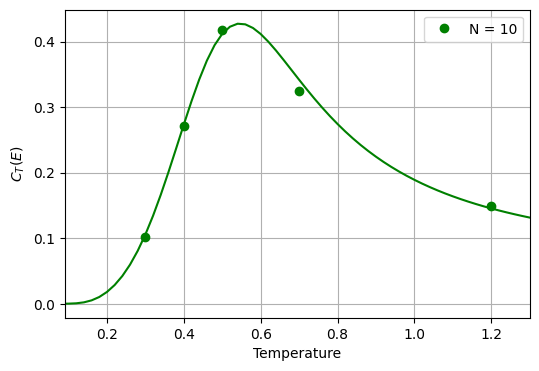

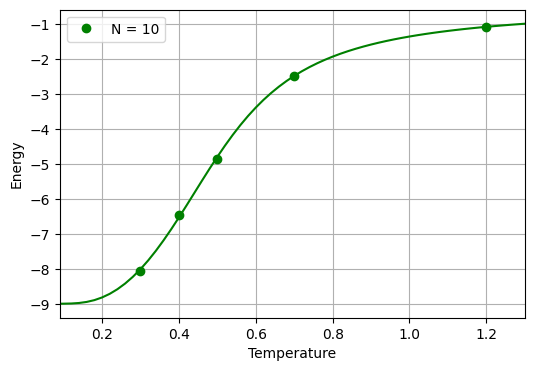

max: 0.5399999999999994  val max: 0.4271698442181272


In [14]:
range_temperatures = np.arange(1.3, 0.05, -0.02)
print(range_temperatures)
C,E = calculate_C(N, range_temperatures, n, Z_new, possible_energies, N_energy, energies_aftereq)
#C,E = calculate_C(N, range_temperatures, n, Z_new, possible_energies, N_energy_unc, energies_unc)
print(len(range_temperatures))
print(C)

plt.figure(figsize=(6,4))
plt.plot(range_temperatures, C, linestyle='-', color='green')
plt.plot(temperatures, [mean_varenergy_unc[T] for T in temperatures], marker='o', linestyle='none', color='green', label='N = 10')
plt.xlabel('Temperature')
plt.ylabel('$C_T (E)$')
plt.xlim( 0.09, 1.3)
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(6,4))
plt.plot(temperatures, [mean_energy_aftereq[T] for T in temperatures], marker='o', linestyle='none', color='green', label='N = 10')
plt.plot(range_temperatures, E, linestyle='-', color='green')
plt.ylabel('Energy')
plt.xlabel('Temperature')
plt.xlim( 0.09, 1.3)
plt.legend()
plt.grid()
plt.show()

m = np.argmax(C)
print(f'max: {range_temperatures[m]}  val max: {C[m]}')

# Results after testing the method with different polymer lengths 

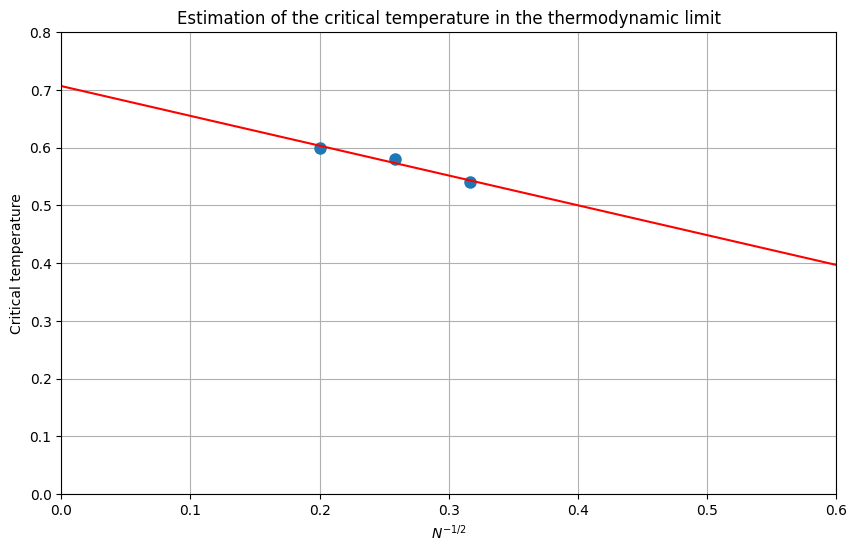

Fit results: a = -0.52 ± 0.10, b = 0.71 ± 0.03


In [27]:
# Temperatures at which the energy fluctuation are maximum
t10 = 0.5399999999999994
t15 = 0.5799999999999994
t25 =  0.5999999999999994

nsmall = 1 / np.sqrt(10)
nmedium = 1 / np.sqrt(15)
nbig = 1 / np.sqrt(25)

lengths = [nbig, nmedium, nsmall]
max_temps = [t25, t15, t10]

def linear_fit(x, a, b):
    return a * x + b

# Linear fit 
popt, pcov = curve_fit(linear_fit, lengths, max_temps)
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))

# Genera i dati del fit
x_fit = np.linspace(0, 0.6, 200)
y_fit = linear_fit(x_fit, a, b)

# Plot dei dati e del fit lineare
plt.figure(figsize=(10, 6))
plt.plot(lengths, max_temps, 'o', label='Data', markersize=8)
plt.plot(x_fit, y_fit, '-', label=f'Fit: $y = {a:.2f}x + {b:.2f}$', color='red')
plt.xlabel(r'$N^{-1/2}$')
plt.ylabel('Critical temperature')
plt.ylim(0, 0.8)
plt.xlim(0,0.6)
plt.title('Estimation of the critical temperature in the thermodynamic limit')
plt.grid(True)
plt.show()

# Stampa dei risultati del fit
print(f'Fit results: a = {a:.2f} ± {a_err:.2f}, b = {b:.2f} ± {b_err:.2f}')